In [1]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 음수 부호 깨짐 방지

## 공통 데이터

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

rng = np.random.default_rng(13)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

---
## Q1

### Q1(a)

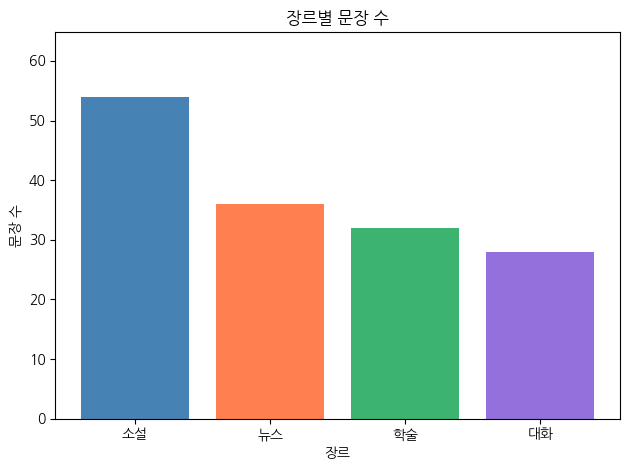

In [3]:
genre_counts = texts['장르'].value_counts()

fig, ax = plt.subplots()
ax.bar(genre_counts.index, genre_counts.values, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
ax.set_ylim(0, genre_counts.max() * 1.2)
plt.tight_layout()
plt.show()

`value_counts()`로 장르별 빈도를 구한 뒤 `ax.bar`로 막대 그래프를 그렸다. `set_ylim(0, ...)`으로 y축이 0부터 시작하게 했다. 뉴스와 소설이 각각 30%의 비율로 가장 많고, 대화와 학술이 각각 20%로 적게 나타났다.

### Q1(b)

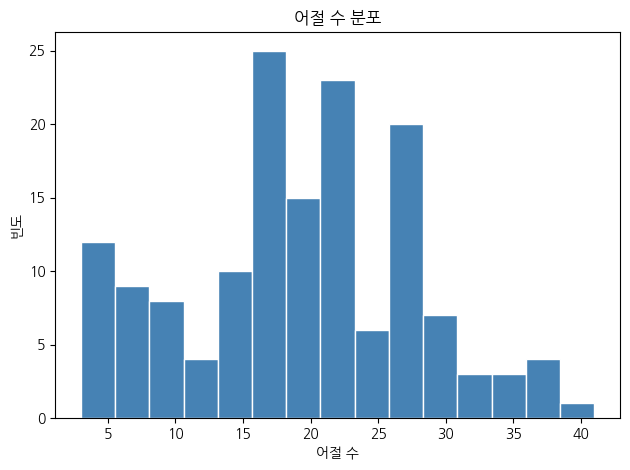

In [4]:
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white', color='steelblue')
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()

어절 수는 주로 10~25 구간에 집중되어 있으며, 이는 뉴스·소설·대화 장르가 전체의 80%를 차지하기 때문이다.

### Q1(c)

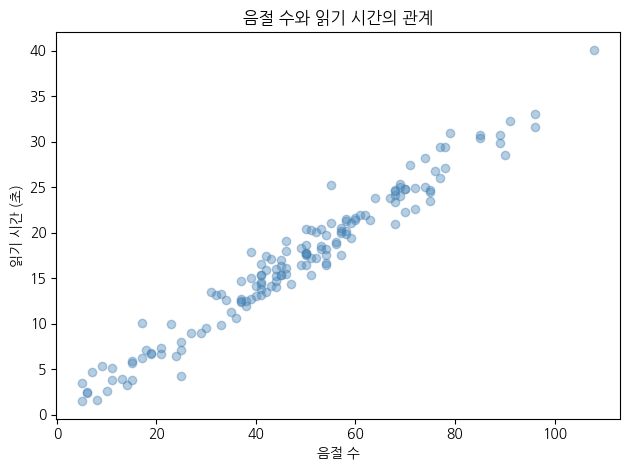

In [5]:
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.4, color='steelblue')
ax.set_title('음절 수와 읽기 시간의 관계')
ax.set_xlabel('음절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.tight_layout()
plt.show()

음절 수가 많을수록 읽기 시간도 증가하는 우상향 관계를 보이며, 이는 읽기 시간이 음절 수에 비례해 계산되었기 때문이다.

"우상향"

---
## Q2

### Q2(a)

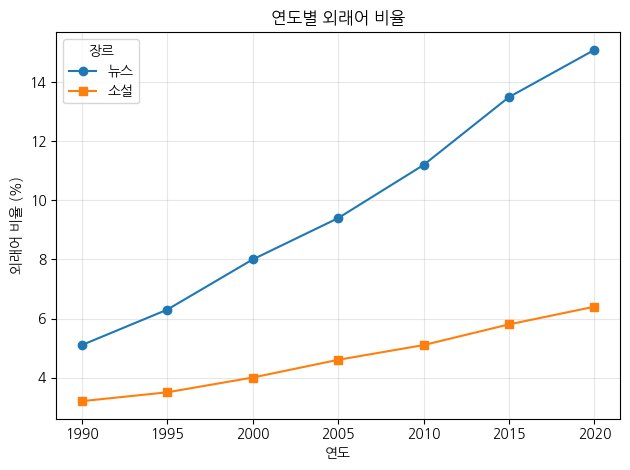

In [6]:
fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율 (%)')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

뉴스의 외래어 비율이 소설보다 훨씬 빠르게 증가하여 1990년 대비 2020년에 약 3배로 커졌지만, 소설은 완만하게 증가했다.

### Q2(b)

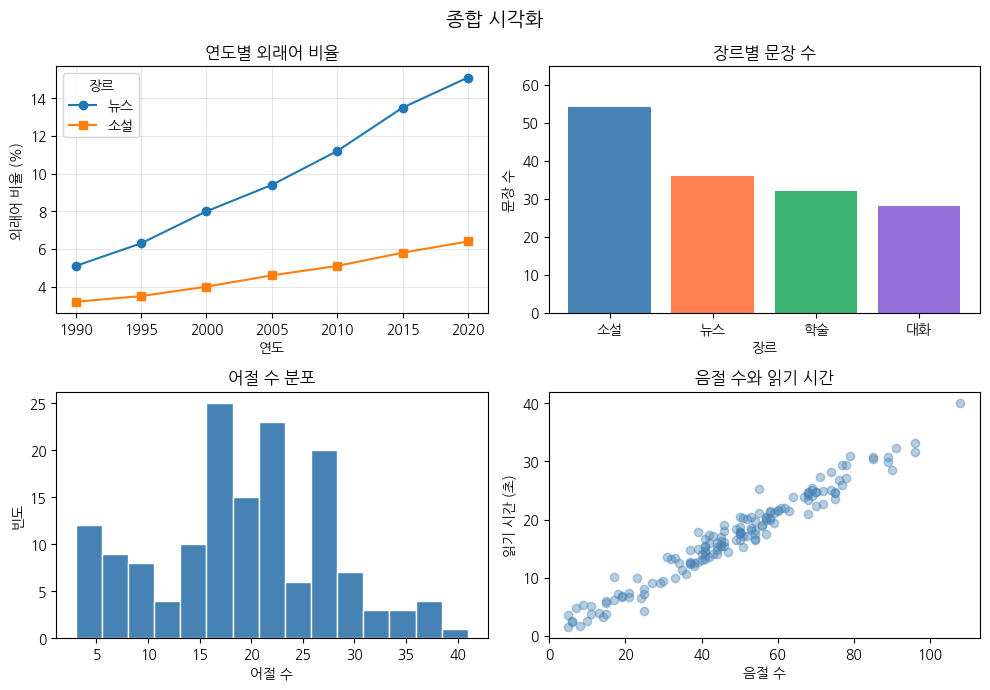

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# axes[0, 0]
axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].set_title('연도별 외래어 비율')
axes[0, 0].set_xlabel('연도')
axes[0, 0].set_ylabel('외래어 비율 (%)')
axes[0, 0].legend(title='장르')
axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1]
genre_counts = texts['장르'].value_counts()
axes[0, 1].bar(genre_counts.index, genre_counts.values,
               color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[0, 1].set_title('장르별 문장 수')
axes[0, 1].set_xlabel('장르')
axes[0, 1].set_ylabel('문장 수')
axes[0, 1].set_ylim(0, genre_counts.max() * 1.2)

# axes[1, 0]
axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white', color='steelblue')
axes[1, 0].set_title('어절 수 분포')
axes[1, 0].set_xlabel('어절 수')
axes[1, 0].set_ylabel('빈도')

# axes[1, 1]
axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.4, color='steelblue')
axes[1, 1].set_title('음절 수와 읽기 시간')
axes[1, 1].set_xlabel('음절 수')
axes[1, 1].set_ylabel('읽기 시간 (초)')

fig.suptitle('종합 시각화', fontsize=14)
fig.tight_layout()
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

`plt.subplots(2, 2, figsize=(10, 7))`로 2×2 격자를 만들고, 'fig.savefig`로 PNG 파일로 저장함

---
## Q3

### Q3(a)

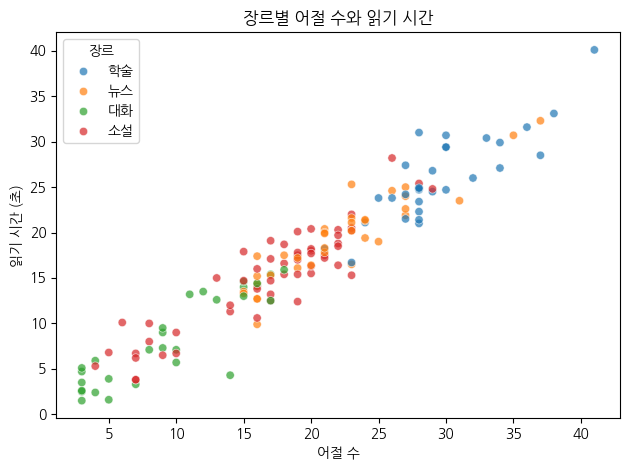

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', alpha=0.7, ax=ax)
ax.set_title('장르별 어절 수와 읽기 시간')
ax.set_xlabel('어절 수')
ax.set_ylabel('읽기 시간 (초)')
plt.tight_layout()
plt.show()

어절수와 읽기시간은 장르와 무관하게 전반적으로 우상향 관계를 보인다.

### Q3(b)

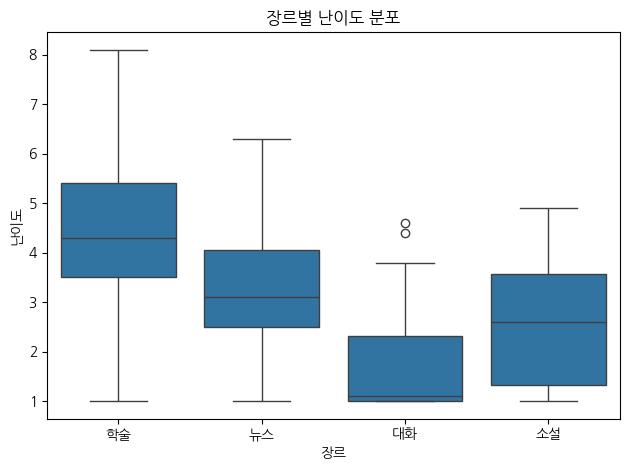

In [10]:
fig, ax = plt.subplots()
sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
ax.set_title('장르별 난이도 분포')
ax.set_xlabel('장르')
ax.set_ylabel('난이도')
plt.tight_layout()
plt.show()

가장 난이도가 높은 장르는 학술이며, 분산이 가장 큰 장르도 학술로 텍스트마다 난이도 편차가 크다는 것을 보여준다.

### Q3(c)

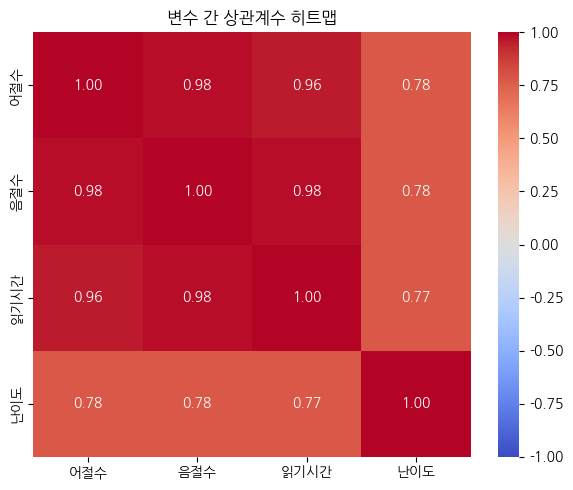

In [11]:
corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title('변수 간 상관계수 히트맵')
plt.tight_layout()
plt.show()

음절수와 읽기시간이 가장 강하게 함께 증가하는데, 이는 읽기시간이 음절수에 직접 비례해 계산되었기 때문이다.

---
## Q4

### Q4(a)

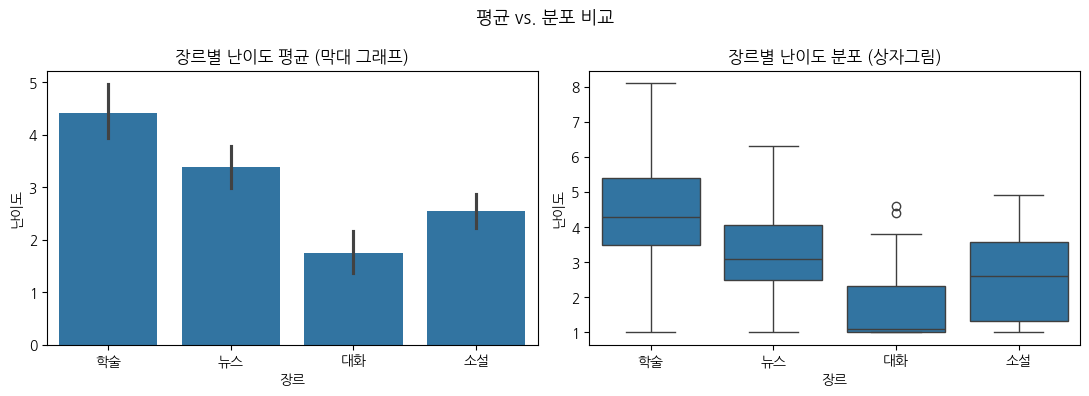

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽:
sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도 평균 (막대 그래프)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('난이도')

# 오른쪽:
sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
axes[1].set_title('장르별 난이도 분포 (상자그림)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('난이도')

fig.suptitle('평균 vs. 분포 비교', fontsize=13)
fig.tight_layout()
plt.show()

왼쪽 막대 그래프("다이너마이트 플롯")는 장르별 평균값만 보여주어 분포의 형태, 중앙값, 이상값 등이 숨겨진다.

예를 들어 뉴스와 소설의 평균 난이도가 비슷하더라도, 한 장르는 난이도가 균일하고 다른 장르는 쉬운 것과 어려운 것이 섞여 있을 수 있는데 막대 그래프로는 이를 전혀 알 수 없다.

### Q4(b)

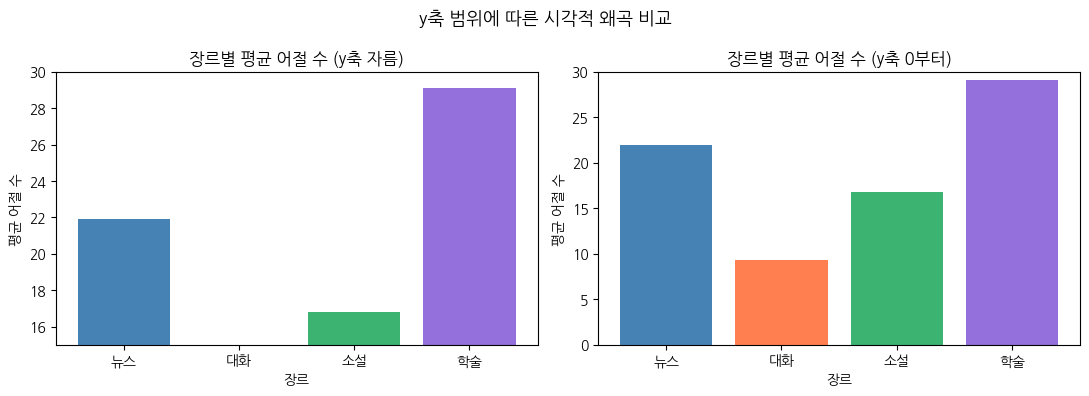

In [13]:
mean_words = texts.groupby('장르')['어절수'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 왼쪽
axes[0].bar(mean_words.index, mean_words.values,
            color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[0].set_ylim(15, 30)
axes[0].set_title('장르별 평균 어절 수 (y축 자름)')
axes[0].set_xlabel('장르')
axes[0].set_ylabel('평균 어절 수')

# 오른쪽
axes[1].bar(mean_words.index, mean_words.values,
            color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[1].set_ylim(0, 30)
axes[1].set_title('장르별 평균 어절 수 (y축 0부터)')
axes[1].set_xlabel('장르')
axes[1].set_ylabel('평균 어절 수')

fig.suptitle('y축 범위에 따른 시각적 왜곡 비교', fontsize=13)
fig.tight_layout()
plt.show()

왼쪽 그래프는 y축을 15에서 잘라 대화 장르의 막대가 거의 없고 학술 장르의 막대가 훨씬 커 보인다. 오른쪽은 실제 비율대로 표현되어 안정적인 인상이다.

y축이 0에서 시작하지 않으면 길이 비율이 왜곡되기 때문이다.